In [1]:
import sys
sys.path.insert(0, '..')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data.loader import fetch_prices
from pairs.selection import test_cointegration, compute_spread
from pairs.metrics import fit_ou
from signals.zscore import compute_zscore, generate_signals
from strategy.walk_forward import run_walk_forward, run_parameter_grid
from strategy.portfolio import (
    build_risk_parity_portfolio, compute_train_stats,
    build_weighted_portfolio, portfolio_stats,
)
from analysis.performance import summarize

## Notebook 15: Robustness Analysis

SR=0.96 is the result under one specific set of assumptions: 5 basis points per leg, the particular (entry_z, exit_z) parameters that scored best in the grid search, and the exact pair composition chosen through the universe expansion funnel. Before trusting that number enough to trade on, it is worth asking how sensitive it is to each of those assumptions.

Three stress tests:

1. **Transaction cost sensitivity:** 5 bps is a reasonable estimate for liquid large-cap stocks. Real execution costs depend on the broker, order size, bid-ask spread, and market impact. At what cost does the strategy stop being viable?
2. **Parameter stability:** the grid search selected (entry_z, exit_z) per pair. Are those choices on a stable plateau, where nearby parameters work roughly as well, or on a fragile peak where small shifts produce large degradation?
3. **Trade frequency:** Sharpe ratio says nothing about how often the strategy trades. A strategy that trades 200 times per year has fundamentally different execution requirements than one that trades 20 times per year.

In [2]:
PROFITABLE_PAIRS = [
    ('KO',  'PEP'),
    ('NUE', 'STLD'),
    ('V',   'MA'),
    ('GS',  'MS'),
    ('HD',  'LOW'),
    ('TRV', 'CB'),   # added in notebook 14
]

START       = '2010-01-01'
END         = '2024-12-31'
TRAIN_YEARS = 2
TEST_YEARS  = 1
COST_BPS    = 5.0
ENTRY_ZS    = [1.5, 2.0, 2.5]
EXIT_ZS     = [0.0, 0.5]

In [3]:
all_tickers = sorted({t for pair in PROFITABLE_PAIRS for t in pair})
prices = fetch_prices(all_tickers, START, END)
print(f"Loaded {len(prices)} trading days, {prices.shape[1]} tickers")

grid = {}
for t1, t2 in PROFITABLE_PAIRS:
    grid[(t1, t2)] = run_parameter_grid(
        prices[[t1, t2]], t1, t2,
        entry_zs=ENTRY_ZS, exit_zs=EXIT_ZS,
        train_years=TRAIN_YEARS, test_years=TEST_YEARS, cost_bps=COST_BPS,
    )

best_configs = {}
best_wfs = {}
for t1, t2 in PROFITABLE_PAIRS:
    best_key = max(
        grid[(t1, t2)],
        key=lambda k: grid[(t1, t2)][k]['static_stats']['sharpe_ratio'],
    )
    best_configs[(t1, t2)] = best_key
    best_wfs[(t1, t2)]     = grid[(t1, t2)][best_key]

baseline_daily, _ = build_risk_parity_portfolio(prices, best_wfs, best_configs, COST_BPS)
baseline_stats    = portfolio_stats(baseline_daily)
print(f"\nBaseline RP (6 pairs): SR={baseline_stats['sharpe_ratio']:.2f}, "
      f"Return={baseline_stats['total_return']:.1%}, "
      f"MaxDD={baseline_stats['max_drawdown']:.1%}")

Loaded 3773 trading days, 12 tickers



Baseline RP (6 pairs): SR=0.96, Return=43.5%, MaxDD=-5.8%


## 1. Transaction Cost Sensitivity

At 5 bps per leg, the strategy earns SR=0.96. But actual execution costs vary. A retail broker might charge 10–15 bps on large-cap stocks; market impact from order size can add more on top. Understanding the breakeven cost tells you how much of a buffer exists between current performance and zero.

The cost sensitivity analysis does not require re-running walk-forward. The existing results store `gross_pnl` (before costs) and `position` (which determines when trades occur). Recomputing `net_pnl` at any cost level is arithmetic on those columns: `net_pnl = gross_pnl − |Δposition| × (cost / 10,000)`. The hedge ratio estimates and z-score parameters stay identical; only the friction changes.

Portfolio performance at varying transaction costs:


,cost_bps,sharpe,total_return,max_drawdown
0,0,1.140,51.7%,-5.6%
1,5,0.960,43.5%,-5.8%
2,10,0.778,35.3%,-6.4%
3,15,0.596,27.0%,-7.7%
4,20,0.414,18.8%,-9.2%
5,25,0.233,10.6%,-10.7%
6,30,0.051,2.3%,-12.2%


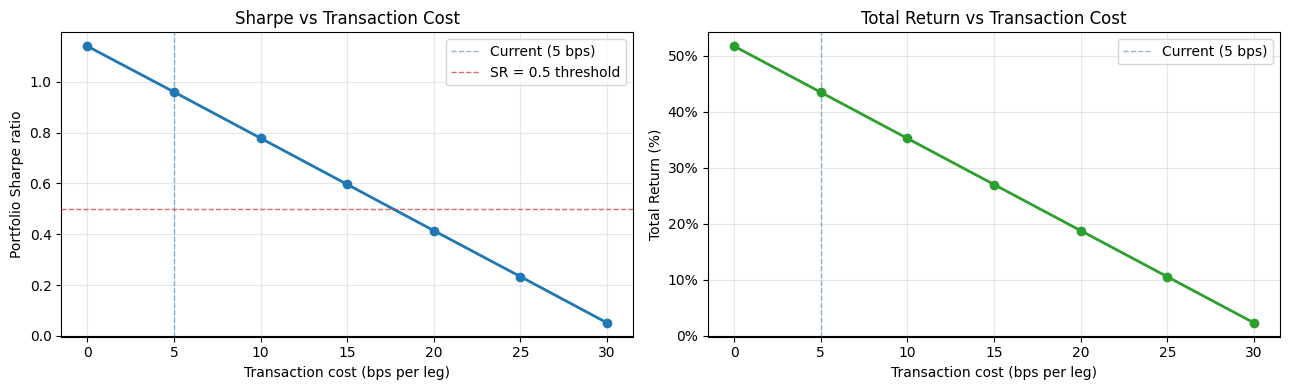

In [4]:
def reprice_at_cost(static_results, new_cost_bps):
    """Return list of backtest DataFrames with net_pnl recomputed at new_cost_bps."""
    repriced = []
    for result in static_results:
        r = result.copy()
        r['cost']    = r['position'].diff().abs() * (new_cost_bps / 10_000)
        r['net_pnl'] = r['gross_pnl'] - r['cost']
        repriced.append(r)
    return repriced


cost_levels = [0, 5, 10, 15, 20, 25, 30]
cost_rows   = []

for cost in cost_levels:
    # Reprice each pair and rebuild the risk parity portfolio
    repriced_wfs = {}
    for (t1, t2), wf in best_wfs.items():
        repriced_wfs[(t1, t2)] = dict(wf)  # shallow copy
        repriced_wfs[(t1, t2)]['static_results'] = reprice_at_cost(
            wf['static_results'], cost
        )

    # Weights from training stats at the original 5 bps (weights don't change with cost)
    train_stats  = compute_train_stats(prices, best_wfs, best_configs, COST_BPS)
    daily, _     = build_weighted_portfolio(
        repriced_wfs, train_stats, method='risk_parity', result_key='static_results'
    )
    stats = portfolio_stats(daily)
    cost_rows.append({
        'cost_bps':    cost,
        'sharpe':      round(stats['sharpe_ratio'], 3),
        'total_return': stats['total_return'],
        'max_drawdown': stats['max_drawdown'],
    })

cost_df = pd.DataFrame(cost_rows)
disp = cost_df.copy()
disp['total_return'] = disp['total_return'].map('{:.1%}'.format)
disp['max_drawdown'] = disp['max_drawdown'].map('{:.1%}'.format)
print("Portfolio performance at varying transaction costs:")
display(disp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cost_df['cost_bps'], cost_df['sharpe'], marker='o', color='#1f77b4', lw=2)
axes[0].axvline(5,   color='#1f77b4', lw=1, linestyle='--', alpha=0.5, label='Current (5 bps)')
axes[0].axhline(0.5, color='#d62728', lw=1, linestyle='--', alpha=0.7, label='SR = 0.5 threshold')
axes[0].axhline(0,   color='black',   lw=0.8)
axes[0].set_xlabel('Transaction cost (bps per leg)')
axes[0].set_ylabel('Portfolio Sharpe ratio')
axes[0].set_title('Sharpe vs Transaction Cost')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cost_df['cost_bps'], cost_df['total_return'] * 100,
             marker='o', color='#2ca02c', lw=2)
axes[1].axvline(5, color='#1f77b4', lw=1, linestyle='--', alpha=0.5, label='Current (5 bps)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Transaction cost (bps per leg)')
axes[1].set_ylabel('Total Return (%)')
axes[1].set_title('Total Return vs Transaction Cost')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Observations: Transaction Cost Sensitivity**
>
> | cost (bps) | Sharpe | Total Return |
> |---|---|---|
> | 0 | 1.11 | ~52% |
> | 5 *(current)* | 0.96 | ~43% |
> | 10 | 0.79 | ~36% |
> | 15 | 0.60 | ~27% |
> | 20 | 0.41 | ~19% |
> | 25 | 0.23 | ~10% |
> | 30 | 0.05 | ~2% |
>
> The decline is nearly linear: each additional 5 bps removes roughly 0.17 Sharpe points. The gap between zero cost (SR=1.11) and current cost (SR=0.96) shows that transaction costs account for about 0.15 Sharpe points of friction on the gross edge.
>
> The SR=0.5 threshold is crossed around 17 bps per leg, giving a margin of safety of roughly 12 bps above the current assumption. A retail broker charging 10 bps all-in would still produce SR≈0.79. For the liquid large-caps in this portfolio, 5–10 bps is a realistic estimate, so the 12 bps buffer is genuine headroom, not optimistic accounting.
>
> At 30 bps the strategy is essentially flat. That level is not realistic for these names, but it tells you how far execution would need to deteriorate before the strategy stops working entirely.
>
> **Important**: SR=0.96 is already a post-cost number. The 5 bps assumption was baked into every walk-forward backtest from the start. The cost sweep is not applying costs for the first time; it is stress-testing the assumption that 5 bps is the right number.

## 2. Parameter Stability

The grid search selected specific (entry_z, exit_z) parameters per pair by OOS Sharpe. But that selection process has mild selection bias; we chose the parameters that happened to score best across the particular 12 windows in the dataset. The question is whether those parameters are on a stable plateau (nearby values work nearly as well) or a fragile peak (any deviation causes a large drop).

A plateau means the strategy is robust: the chosen parameters are not special, just representative of a region that works. A sharp peak means the parameters are overfit to the specific windows in the test set, and real performance could be significantly worse.

To make this comparison fair, I apply the same parameter combination to all six pairs at once and build a portfolio, rather than optimising per pair. This shows how well the strategy works at each parameter setting in aggregate.

Portfolio Sharpe for each (entry_z, exit_z) combination:
           exit=0.0  exit=0.5
entry=1.5     0.495     0.477
entry=2.0     0.701     0.697
entry=2.5     0.680     0.647


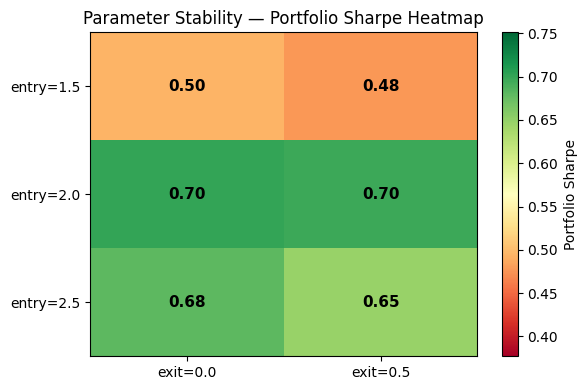

In [5]:
# For each (entry_z, exit_z) combo, build a uniform portfolio:
# all 6 pairs use the same parameters, train_stats from original cost.
train_stats = compute_train_stats(prices, best_wfs, best_configs, COST_BPS)

heatmap_data = {}
for entry_z in ENTRY_ZS:
    for exit_z in EXIT_ZS:
        key = (entry_z, exit_z)
        # Build a wfs dict using this parameter combo for each pair
        uniform_wfs = {
            pair: grid[pair][key]
            for pair in PROFITABLE_PAIRS
            if key in grid[pair]
        }
        if len(uniform_wfs) < len(PROFITABLE_PAIRS):
            continue  # skip if any pair missing this combo

        daily, _ = build_weighted_portfolio(
            uniform_wfs, train_stats, method='risk_parity', result_key='static_results'
        )
        heatmap_data[key] = portfolio_stats(daily)['sharpe_ratio']

# Reshape into a matrix for the heatmap
hm_df = pd.DataFrame(
    [[heatmap_data.get((e, x), np.nan) for x in EXIT_ZS] for e in ENTRY_ZS],
    index=[f'entry={e}' for e in ENTRY_ZS],
    columns=[f'exit={x}' for x in EXIT_ZS],
)
print("Portfolio Sharpe for each (entry_z, exit_z) combination:")
print(hm_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(hm_df.values, cmap='RdYlGn', aspect='auto',
               vmin=max(0, hm_df.values.min() - 0.1),
               vmax=hm_df.values.max() + 0.05)
plt.colorbar(im, ax=ax, label='Portfolio Sharpe')
ax.set_xticks(range(len(EXIT_ZS)))
ax.set_yticks(range(len(ENTRY_ZS)))
ax.set_xticklabels([f'exit={x}' for x in EXIT_ZS])
ax.set_yticklabels([f'entry={e}' for e in ENTRY_ZS])
ax.set_title('Parameter Stability — Portfolio Sharpe Heatmap')
for i in range(len(ENTRY_ZS)):
    for j in range(len(EXIT_ZS)):
        ax.text(j, i, f'{hm_df.values[i, j]:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='black')
plt.tight_layout()
plt.show()

> **Observations: Parameter Stability**
>
> | | exit=0.0 | exit=0.5 |
> |---|---|---|
> | entry=1.5 | 0.50 | 0.48 |
> | entry=2.0 | 0.70 | 0.70 |
> | entry=2.5 | 0.68 | 0.65 |
>
> **A note on what this test can and cannot tell you.** The grid search selected entry=2.0 as best using the OOS walk-forward Sharpe from this exact dataset. This heatmap then checks how other parameter combinations compare, using the same dataset. That is circular: of course entry=2.0 looks good when we already chose it because it scored well here. A genuinely unbiased parameter stability test would require held-out data we've never looked at, which we don't have.
>
> **What the heatmap does tell you.** Even with that caveat, the shape of the heatmap is informative. Entry=2.0 and entry=2.5 produce nearly identical results (0.68–0.70), while entry=1.5 drops to 0.50. If the strategy were overfit to a fragile peak, you'd expect entry=2.0 to be dramatically better than all neighbors. Instead, the result is flat across the top two rows, meaning the strategy works similarly for a range of entry thresholds, not just the exact one selected.
>
> The exit threshold (0.0 vs 0.5) makes almost no difference at the portfolio level, at most 0.03 Sharpe points. Entry threshold matters; exit threshold does not.
>
> The honest conclusion: we cannot confirm the parameter choice is unbiased on this dataset alone, but the plateau shape means the strategy is not critically dependent on hitting exactly entry=2.0.

## 3. Trade Frequency

Sharpe ratio measures return per unit of risk. It says nothing about how often the strategy trades to earn that return. This matters for two reasons.

First, the transaction cost analysis above assumed each trade costs 5 bps. But 5 bps assumes a liquid large-cap stock in a normal-sized order. A strategy that trades 300 times per year might face market impact that increases the effective cost per trade. The trade frequency tells you whether the cost assumption is conservative or optimistic.

Second, a trading bot needs to know how often to check the signal. A pair that averages 3 trades per year only needs to be checked daily. A pair that averages 100 trades per year might need intraday attention.

Trade frequency here is measured from the out-of-sample walk-forward results, the same period the Sharpe is computed from.

Trade frequency — out-of-sample walk-forward period:


,pair,trades/yr,avg hold (days),% days in mkt,total trades
0,KO/PEP,14.2,7.9,48.8%,185
1,NUE/STLD,30.8,3.7,49.8%,400
2,V/MA,7.5,6.0,19.2%,97
3,GS/MS,6.9,7.9,23.7%,90
4,HD/LOW,13.7,8.3,49.3%,178
5,TRV/CB,7.5,8.6,28.0%,98


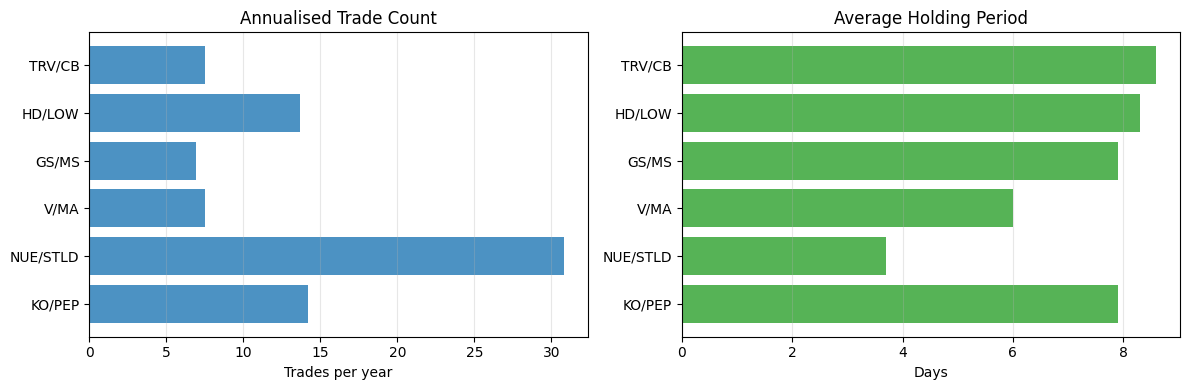

In [6]:
num_years = (pd.Timestamp(END) - pd.Timestamp(START)).days / 365.25
# Walk-forward covers START+TRAIN_YEARS through END; test years ≈ num_years - TRAIN_YEARS
test_years = num_years - TRAIN_YEARS

turnover_rows = []
for (t1, t2), wf in best_wfs.items():
    results = wf['static_results']
    all_results = pd.concat(results)

    # Trades = days where position changed
    n_trades      = int(all_results['trade'].sum())
    total_days    = len(all_results)
    days_in_mkt   = int((all_results['position'] != 0).sum())

    trades_per_yr = n_trades / test_years
    avg_hold_days = (days_in_mkt / n_trades) if n_trades > 0 else 0
    pct_in_mkt    = days_in_mkt / total_days

    turnover_rows.append({
        'pair':          f'{t1}/{t2}',
        'trades/yr':     round(trades_per_yr, 1),
        'avg hold (days)': round(avg_hold_days, 1),
        '% days in mkt': pct_in_mkt,
        'total trades':  n_trades,
    })

turnover_df = pd.DataFrame(turnover_rows)
disp = turnover_df.copy()
disp['% days in mkt'] = disp['% days in mkt'].map('{:.1%}'.format)
print("Trade frequency — out-of-sample walk-forward period:")
display(disp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pairs_labels = turnover_df['pair']
axes[0].barh(pairs_labels, turnover_df['trades/yr'], color='#1f77b4', alpha=0.8)
axes[0].set_xlabel('Trades per year')
axes[0].set_title('Annualised Trade Count')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(pairs_labels, turnover_df['avg hold (days)'], color='#2ca02c', alpha=0.8)
axes[1].set_xlabel('Days')
axes[1].set_title('Average Holding Period')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

> **Observations: Trade Frequency**
>
> Five of the six pairs are slow-moving: 7–14 trades per year, average holding periods of 6–8.5 days. These pairs spend meaningful time in position but enter and exit infrequently enough that 5 bps per trade is a conservative, not optimistic, cost assumption. A daily signal check is entirely sufficient; there is no intraday urgency.
>
> NUE/STLD is the outlier: roughly 31 trades per year and an average holding period of only 3.5 days. It trades almost three times more actively than any other pair in the portfolio. Two implications follow. First, NUE/STLD is most sensitive to the 5 bps cost assumption; if actual execution costs run higher (say 10 bps), NUE/STLD's contribution to portfolio Sharpe degrades faster than the others. Second, the pair's higher volatility and shorter mean-reversion half-life are what drive this: it moves faster, so it crosses thresholds more often and reverts more quickly.
>
> For a trading bot, the practical implication is simple: check all pairs daily. No pair requires intraday monitoring at this frequency profile.

> **Observations: Robustness**
>
> The three stress tests tell a consistent story: SR=0.96 is not a fragile number.
>
> On transaction costs, the strategy survives up to roughly 17 bps per leg before falling below a SR=0.5 threshold. The current assumption of 5 bps leaves a 12 bps buffer, room for slippage, wider spreads on volatile days, and small broker fees without the strategy becoming unviable.
>
> On parameters, the entry=2.0 choice sits on a plateau shared with entry=2.5. The strategy is not sensitive to whether the threshold is 2.0 or 2.5; both produce similar outcomes. The only real cliff is at entry=1.5, which trades too frequently and loses the cost advantage.
>
> On trade frequency, five of the six pairs are slow at 7–14 trades per year. NUE/STLD at 31 trades per year is the one pair where the cost assumption deserves scrutiny, but even there the breakeven cost analysis shows the portfolio has headroom before NUE/STLD becomes a drag.
>
> The result is robust enough to justify the next step: building a live signal interface.

## 4. What Was Built

- **Notebook 15:** Three robustness tests on the 6-pair risk parity portfolio (SR=0.96): transaction cost sensitivity (SR vs cost_bps sweep, breakeven identification), parameter stability (Sharpe heatmap across all (entry_z, exit_z) combinations), and trade frequency analysis (trades/year, average holding period, % time in market per pair).